# 🍷 Polinom Regresyon (Polynomial Regression)
### Kırmızı Şarap Kalitesi Verisi Üzerinde Kapsamlı Analiz

---

> **Bu notebook**, gerçek kırmızı şarap fizikokimyasal ölçüm verileri kullanılarak
> polinom regresyonun adım adım, detaylı biçimde açıklandığı bir eğitim kaynağıdır.

| 📌 Konu | Polinom Regresyon |
|--------|-----------------|
| 🗂️ Veri Seti | Wine Quality — Red Wine (1.599 gözlem) |
| 🎯 Hedef | Alkol (`alcohol`) → Kalite (`quality`) ve Uçucu Asitlik (`volatile acidity`) → Kalite Tahmini |
| 🛠️ Araçlar | scikit-learn, NumPy, Pandas, Matplotlib, Seaborn |

---

## 📦 Kütüphanelerin İçe Aktarılması

Aşağıdaki hücrede kullanacağımız tüm kütüphaneler yükleniyor:

| Kütüphane | Kullanım Amacı |
|-----------|---------------|
| `numpy` | Sayısal hesaplamalar, dizi işlemleri |
| `pandas` | Veri okuma, temizleme, manipülasyon |
| `matplotlib` | Temel grafik çizimi |
| `seaborn` | İstatistiksel görselleştirme |
| `PolynomialFeatures` | $x → [1, x, x^2, \ldots, x^n]$ dönüşümü |
| `LinearRegression` | OLS (En Küçük Kareler) ile katsayı tahmini |
| `make_pipeline` | Ön işleme + model adımlarını zincir haline getirir |
| `train_test_split` | Veriyi eğitim/test olarak böler |
| `r2_score`, `mean_squared_error` | Model performans metrikleri |

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
from matplotlib.patches import FancyArrowPatch

from sklearn.preprocessing import PolynomialFeatures, StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.pipeline import make_pipeline, Pipeline
from sklearn.model_selection import train_test_split, cross_val_score, KFold
from sklearn.metrics import r2_score, mean_squared_error

import warnings
warnings.filterwarnings('ignore')

plt.rcParams['figure.figsize'] = (13, 5)
plt.rcParams['figure.dpi'] = 110
plt.rcParams['axes.spines.top'] = False
plt.rcParams['axes.spines.right'] = False
sns.set_style('whitegrid')
sns.set_palette('husl')

np.set_printoptions(precision=4, suppress=True)

print('✅ Tüm kütüphaneler başarıyla yüklendi.')
print(f'   NumPy  : {np.__version__}')
print(f'   Pandas : {pd.__version__}')

✅ Tüm kütüphaneler başarıyla yüklendi.
   NumPy  : 2.4.4
   Pandas : 3.0.2


##  🗂️ Veri Kümesinin Yüklenmesi ve İlk İnceleme



In [ ]:
df_wine = pd.read_csv('winequality-red.csv')

print('=' * 60)
print('🍷 KIRMIZI ŞARAP KALİTESİ VERİSİ (winequality-red.csv)')
print('=' * 60)
print(f'  Satır sayısı  : {df_wine.shape[0]:,}')
print(f'  Sütun sayısı  : {df_wine.shape[1]}')
print(f'  Kalite aralığı: {df_wine["quality"].min()} → {df_wine["quality"].max()}')
print(f'  Benzersiz kalite skorları: {sorted(df_wine["quality"].unique())}')
print()

print('İlk 5 satır:')
df_wine[['alcohol', 'volatile acidity', 'citric acid', 'sulphates', 'quality']].head()

🍷 KIRMIZI ŞARAP KALİTESİ VERİSİ (winequality-red.csv)
  Satır sayısı  : 1,599
  Sütun sayısı  : 12
  Kalite aralığı: 3 → 8
  Benzersiz kalite skorları: [np.int64(3), np.int64(4), np.int64(5), np.int64(6), np.int64(7), np.int64(8)]

İlk 5 satır:


   alcohol  volatile acidity  citric acid  sulphates  quality
0      9.4              0.70         0.00       0.56        5
1      9.8              0.88         0.00       0.68        5
2      9.8              0.76         0.04       0.65        5
3      9.8              0.28         0.56       0.58        6
4      9.4              0.70         0.00       0.56        5

###  Sütun Veri Tipleri ve Eksik Değer Analizi



In [ ]:
null_counts = df_wine.isnull().sum()
null_pct    = (null_counts / len(df_wine) * 100).round(2)

null_df = pd.DataFrame({
    'Eksik Sayı': null_counts,
    'Eksik Yüzde (%)': null_pct,
    'Veri Tipi': df_wine.dtypes
}).sort_values('Eksik Sayı', ascending=False)

print('📋 Eksik Değer Raporu:')
print(null_df.to_string())
print()
if (null_counts > 0).sum() == 0:
    print('✅ Veri setinde hiç eksik değer yok — temizleme adımı büyük ölçüde basitleşiyor.')
else:
    print(f'⚠️  Toplam {(null_counts > 0).sum()} sütunda eksik veri mevcut.')

📋 Eksik Değer Raporu:
                      Eksik Sayı  Eksik Yüzde (%) Veri Tipi
fixed acidity                  0              0.0   float64
volatile acidity               0              0.0   float64
citric acid                    0              0.0   float64
residual sugar                 0              0.0   float64
chlorides                      0              0.0   float64
free sulfur dioxide            0              0.0   float64
total sulfur dioxide           0              0.0   float64
density                        0              0.0   float64
pH                             0              0.0   float64
sulphates                      0              0.0   float64
alcohol                        0              0.0   float64
quality                        0              0.0     int64

✅ Veri setinde hiç eksik değer yok — temizleme adımı büyük ölçüde basitleşiyor.


###  İstatistiksel Özet



In [ ]:
stats = df_wine[['alcohol', 'volatile acidity', 'citric acid', 'sulphates', 'quality']].describe().round(3)

print('📈 İstatistiksel Özet:')
print(stats)
print()
print('💡 İçgörüler:')
print(f'  • Ortalama alkol oranı   : {stats.loc["mean", "alcohol"]:.2f}%')
print(f'  • Ortalama uçucu asitlik : {stats.loc["mean", "volatile acidity"]:.3f} g/dm³')
print(f'  • Ortalama kalite skoru  : {stats.loc["mean", "quality"]:.2f} / 10')
print(f'  • Alkol aralığı          : {stats.loc["min","alcohol"]:.1f}% → {stats.loc["max","alcohol"]:.1f}%')
print(f'  • Kalite std             : {stats.loc["std","quality"]:.2f}  (skorlar çoğunlukla 5-6 civarında toplanıyor)')

📈 İstatistiksel Özet:
        alcohol  volatile acidity  citric acid  sulphates   quality
count  1599.000          1599.000     1599.000   1599.000  1599.000
mean     10.423             0.528        0.271      0.658     5.636
std       1.066             0.179        0.195      0.170     0.808
min       8.400             0.120        0.000      0.330     3.000
25%       9.500             0.390        0.090      0.550     5.000
50%      10.200             0.520        0.260      0.620     6.000
75%      11.100             0.640        0.420      0.730     6.000
max      14.900             1.580        1.000      2.000     8.000

💡 İçgörüler:
  • Ortalama alkol oranı   : 10.42%
  • Ortalama uçucu asitlik : 0.528 g/dm³
  • Ortalama kalite skoru  : 5.64 / 10
  • Alkol aralığı          : 8.4% → 14.9%
  • Kalite std             : 0.81  (skorlar çoğunlukla 5-6 civarında toplanıyor)


##  🔧 Veri Ön İşleme



In [ ]:
cols = ['alcohol', 'volatile acidity', 'citric acid', 'sulphates', 'quality']
data = df_wine[cols].copy()

for col in cols:
    data[col] = pd.to_numeric(data[col], errors='coerce')

n_before = len(data)
data = data.dropna()
n_after  = len(data)

print(f'🧹 Temizleme Raporu:')
print(f'  Önceki satır sayısı : {n_before:,}')
print(f'  Sonraki satır sayısı: {n_after:,}')
print(f'  Silinen satır sayısı: {n_before - n_after:,} ({(n_before-n_after)/n_before*100:.2f}%)')
print()

print('🔍 IQR Aykırı Değer Analizi:')
for col in ['alcohol', 'volatile acidity', 'citric acid', 'sulphates']:
    Q1  = data[col].quantile(0.25)
    Q3  = data[col].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    outliers = data[(data[col] < lower) | (data[col] > upper)]
    print(f'  {col:18s} | IQR={IQR:.3f} | [{lower:.3f}, {upper:.3f}] | {len(outliers):,} aykırı değer ({len(outliers)/len(data)*100:.2f}%)')

print()
print('✅ Veri temizleme tamamlandı.')
data.head()

🧹 Temizleme Raporu:
  Önceki satır sayısı : 1,599
  Sonraki satır sayısı: 1,599
  Silinen satır sayısı: 0 (0.00%)

🔍 IQR Aykırı Değer Analizi:
  alcohol            | IQR=1.600 | [7.100, 13.500] | 13 aykırı değer (0.81%)
  volatile acidity   | IQR=0.250 | [0.015, 1.015] | 19 aykırı değer (1.19%)
  citric acid        | IQR=0.330 | [-0.405, 0.915] | 1 aykırı değer (0.06%)
  sulphates          | IQR=0.180 | [0.280, 1.000] | 59 aykırı değer (3.69%)

✅ Veri temizleme tamamlandı.


   alcohol  volatile acidity  citric acid  sulphates  quality
0      9.4              0.70         0.00       0.56        5
1      9.8              0.88         0.00       0.68        5
2      9.8              0.76         0.04       0.65        5
3      9.8              0.28         0.56       0.58        6
4      9.4              0.70         0.00       0.56        5

## 📊 Keşifsel Veri Analizi (EDA)

### Değişken Dağılımları


💡 Yorum:
  • Alkol oranı hafif sağa çarpık — çoğu şarap %9-11 bandında, uzun bir üst kuyruk var.
  • Uçucu asitlik de sağa çarpık; yüksek değerler istenmeyen "sirkemsi" tat ile ilişkilendirilir.
  • Sülfat dağılımı da sağa çarpık, birkaç yüksek değerli örnek dağılımı geriyor.


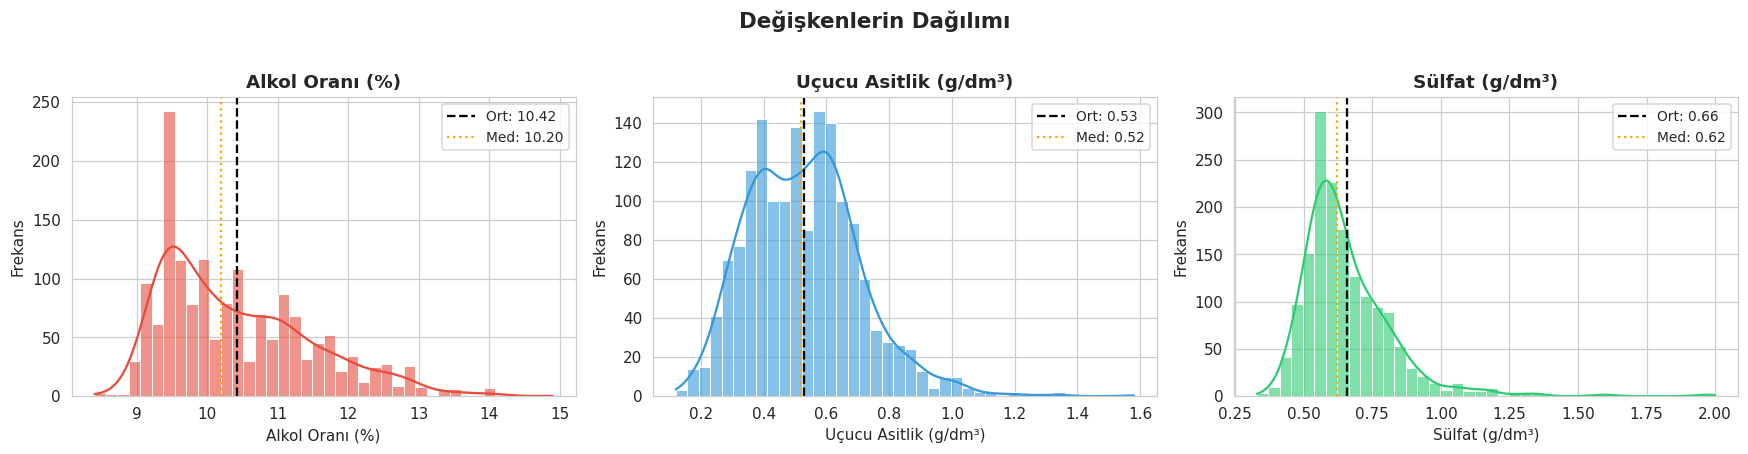

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4))
fig.suptitle('Değişkenlerin Dağılımı', fontsize=14, fontweight='bold', y=1.02)

vars_info = [
    ('alcohol',          '#e74c3c', 'Alkol Oranı (%)'),
    ('volatile acidity',  '#3498db', 'Uçucu Asitlik (g/dm³)'),
    ('sulphates',         '#2ecc71', 'Sülfat (g/dm³)'),
]

for ax, (col, color, label) in zip(axes, vars_info):
    sns.histplot(data[col], bins=40, kde=True, color=color, alpha=0.6, ax=ax)

    mean_val   = data[col].mean()
    median_val = data[col].median()
    ax.axvline(mean_val,   color='black',  linestyle='--', linewidth=1.5, label=f'Ort: {mean_val:.2f}')
    ax.axvline(median_val, color='orange', linestyle=':',  linewidth=1.5, label=f'Med: {median_val:.2f}')

    ax.set_title(label, fontweight='bold')
    ax.set_xlabel(label)
    ax.set_ylabel('Frekans')
    ax.legend(fontsize=9)

plt.tight_layout()
plt.show()

print('💡 Yorum:')
print('  • Alkol oranı hafif sağa çarpık — çoğu şarap %9-11 bandında, uzun bir üst kuyruk var.')
print('  • Uçucu asitlik de sağa çarpık; yüksek değerler istenmeyen "sirkemsi" tat ile ilişkilendirilir.')
print('  • Sülfat dağılımı da sağa çarpık, birkaç yüksek değerli örnek dağılımı geriyor.')

###  Korelasyon Analizi & Scatter Plots


💡 Yorum:
  • Alkol–Kalite korelasyonu           : r = 0.476  (en güçlü pozitif ilişki)
  • Uçucu Asitlik–Kalite korelasyonu    : r = -0.391  (en güçlü negatif ilişki)
  • Korelasyonlar zayıf-orta düzeyde — kalite tek bir değişkenle tam açıklanamıyor,
    çünkü gerçekte kalite birçok fizikokimyasal etkenin bir arada sonucu.


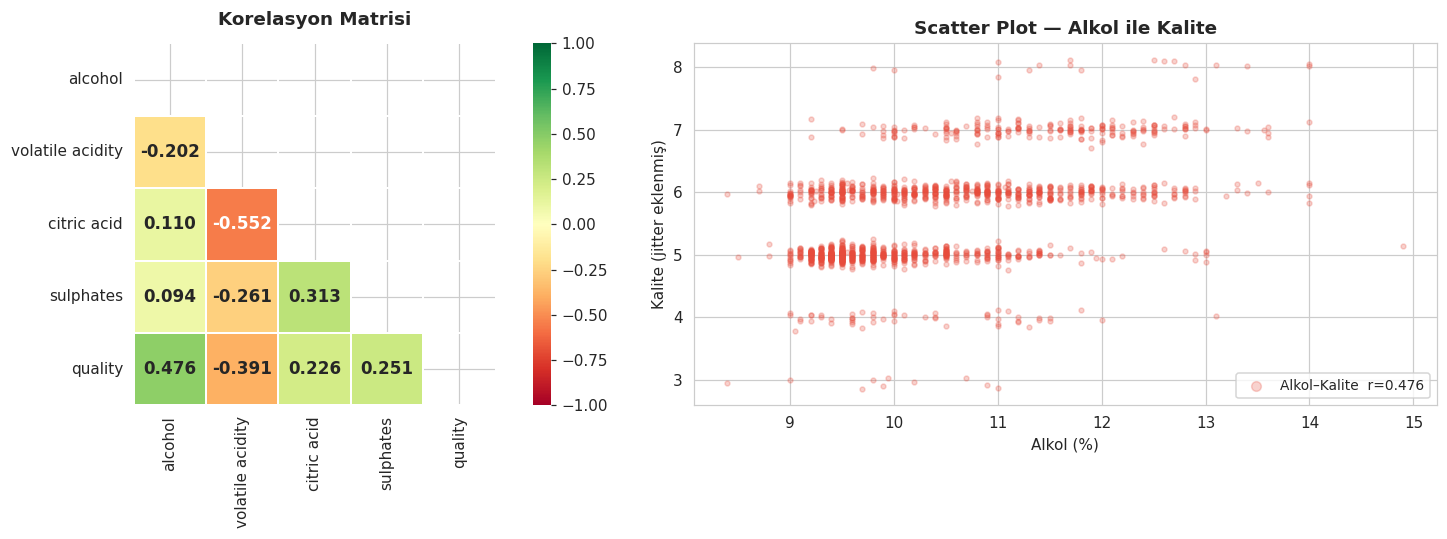

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

corr_matrix = data[['alcohol', 'volatile acidity', 'citric acid', 'sulphates', 'quality']].corr()
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))  # Üst üçgeni gizle
sns.heatmap(
    corr_matrix, mask=mask, annot=True, fmt='.3f',
    cmap='RdYlGn', center=0, vmin=-1, vmax=1,
    square=True, linewidths=1, ax=axes[0],
    annot_kws={'size': 11, 'weight': 'bold'}
)
axes[0].set_title('Korelasyon Matrisi', fontweight='bold', pad=12)

rng = np.random.default_rng(42)
jitter = rng.normal(0, 0.08, size=len(data))
axes[1].scatter(data['alcohol'], data['quality'] + jitter, alpha=0.25, s=10,
                color='#e74c3c', label=f'Alkol–Kalite  r={corr_matrix.loc["alcohol","quality"]:.3f}')
axes[1].set_xlabel('Alkol (%)')
axes[1].set_ylabel('Kalite (jitter eklenmiş)')
axes[1].set_title('Scatter Plot — Alkol ile Kalite', fontweight='bold')
axes[1].legend(fontsize=9, markerscale=2)

plt.tight_layout()
plt.show()

print('💡 Yorum:')
r_alc = corr_matrix.loc['alcohol', 'quality']
r_va  = corr_matrix.loc['volatile acidity', 'quality']
print(f'  • Alkol–Kalite korelasyonu           : r = {r_alc:.3f}  (en güçlü pozitif ilişki)')
print(f'  • Uçucu Asitlik–Kalite korelasyonu    : r = {r_va:.3f}  (en güçlü negatif ilişki)')
print(f'  • Korelasyonlar zayıf-orta düzeyde — kalite tek bir değişkenle tam açıklanamıyor,')
print(f'    çünkü gerçekte kalite birçok fizikokimyasal etkenin bir arada sonucu.')

###  Box Plot — Aykırı Değer Görselleştirmesi



💡 Yorum:
  • Kalite arttıkça medyan alkol oranı belirgin biçimde yükseliyor → pozitif ilişki.
  • Kalite arttıkça medyan uçucu asitlik düşüyor → negatif ilişki.
  • Her kalite grubunda hâlâ geniş bir dağılım var — tek değişken kaliteyi tam açıklamıyor.


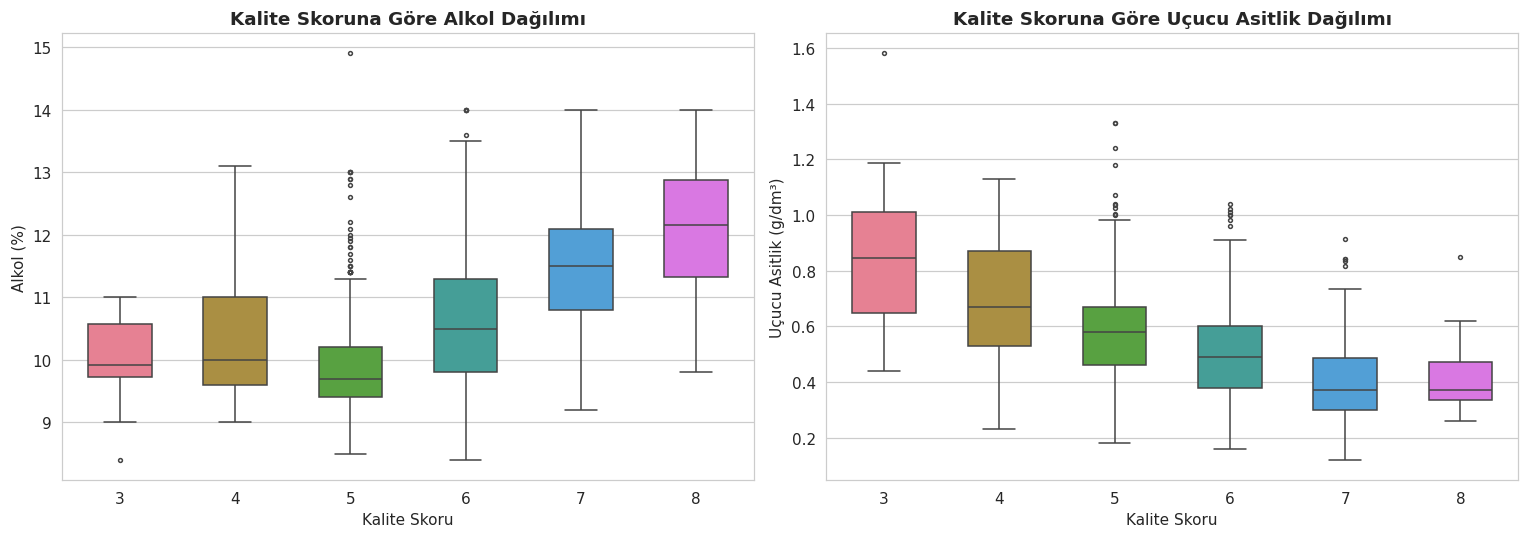

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.boxplot(x='quality', y='alcohol', data=data,
            palette='husl', width=0.55, fliersize=2.5, ax=axes[0])
axes[0].set_title('Kalite Skoruna Göre Alkol Dağılımı', fontweight='bold')
axes[0].set_xlabel('Kalite Skoru')
axes[0].set_ylabel('Alkol (%)')

sns.boxplot(x='quality', y='volatile acidity', data=data,
            palette='husl', width=0.55, fliersize=2.5, ax=axes[1])
axes[1].set_title('Kalite Skoruna Göre Uçucu Asitlik Dağılımı', fontweight='bold')
axes[1].set_xlabel('Kalite Skoru')
axes[1].set_ylabel('Uçucu Asitlik (g/dm³)')

plt.tight_layout()
plt.show()

print('💡 Yorum:')
print('  • Kalite arttıkça medyan alkol oranı belirgin biçimde yükseliyor → pozitif ilişki.')
print('  • Kalite arttıkça medyan uçucu asitlik düşüyor → negatif ilişki.')
print('  • Her kalite grubunda hâlâ geniş bir dağılım var — tek değişken kaliteyi tam açıklamıyor.')

##  🤖 Polinom Regresyon Modeli

###  Train-Test Ayrımı


In [ ]:
# ── Özellik ve hedef değişkeni belirle ───────────────────────────────────
# Bağımsız değişken (X): alcohol
# Bağımlı değişken (y) : quality

X = data[['alcohol']].values   r
y = data['quality'].values

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.20,
    random_state=42
)

print('📊 Veri Bölme Sonuçları:')
print(f'  Toplam veri : {len(X):,} örnek')
print(f'  Eğitim seti : {len(X_train):,} örnek ({len(X_train)/len(X)*100:.0f}%)')
print(f'  Test seti   : {len(X_test):,} örnek  ({len(X_test)/len(X)*100:.0f}%)')
print()
print(f'  X_train boyutu: {X_train.shape}')
print(f'  y_train boyutu: {y_train.shape}')
print()
print('💡 Neden 2D X?')
print('  scikit-learn modelleri X i (n_samples, n_features) formatında bekler.')
print('  data[["alcohol"]].values → (n,1)   ✅')
print('  data["alcohol"].values   → (n,)    ❌ (tek özellik için çalışır ama kötü alışkanlık)')

📊 Veri Bölme Sonuçları:
  Toplam veri : 1,599 örnek
  Eğitim seti : 1,279 örnek (80%)
  Test seti   : 320 örnek  (20%)

  X_train boyutu: (1279, 1)
  y_train boyutu: (1279,)

💡 Neden 2D X?
  scikit-learn modelleri X i (n_samples, n_features) formatında bekler.
  data[["alcohol"]].values → (n,1)   ✅
  data["alcohol"].values   → (n,)    ❌ (tek özellik için çalışır ama kötü alışkanlık)


### Pipeline: PolynomialFeatures + LinearRegression



In [ ]:
print('🔍 PolynomialFeatures Dönüşümü — Somut Örnek:')
print('   Girdi X = [[9.0], [10.5], [12.0]]  (örnek alkol oranları)')
print()

X_example = np.array([[9.0], [10.5], [12.0]])
for degree in [1, 2, 3]:
    pf = PolynomialFeatures(degree=degree, include_bias=True)
    X_transformed = pf.fit_transform(X_example)
    print(f'  Derece {degree}: {X_transformed.tolist()}')
    print(f'    Özellik isimleri: {pf.get_feature_names_out(["alcohol"])}')
    print()

print('💡 "include_bias=True" → Sabit terim (1.0) sütunu eklenir.')
print('   Bu, LinearRegression intercept e karşılık gelir.')

🔍 PolynomialFeatures Dönüşümü — Somut Örnek:
   Girdi X = [[9.0], [10.5], [12.0]]  (örnek alkol oranları)

  Derece 1: [[1.0, 9.0], [1.0, 10.5], [1.0, 12.0]]
    Özellik isimleri: ['1' 'alcohol']

  Derece 2: [[1.0, 9.0, 81.0], [1.0, 10.5, 110.25], [1.0, 12.0, 144.0]]
    Özellik isimleri: ['1' 'alcohol' 'alcohol^2']

  Derece 3: [[1.0, 9.0, 81.0, 729.0], [1.0, 10.5, 110.25, 1157.625], [1.0, 12.0, 144.0, 1728.0]]
    Özellik isimleri: ['1' 'alcohol' 'alcohol^2' 'alcohol^3']

💡 "include_bias=True" → Sabit terim (1.0) sütunu eklenir.
   Bu, LinearRegression intercept e karşılık gelir.


###  Farklı Derecelerde Polinom Modelleri Eğitimi



In [ ]:
degrees = [1, 2, 3, 4, 5, 7, 10]
models  = {}
results = []

for degree in degrees:
    model = make_pipeline(
        PolynomialFeatures(degree=degree, include_bias=True),
        LinearRegression()
    )

    model.fit(X_train, y_train)
    models[degree] = model


    y_train_pred = model.predict(X_train)
    y_test_pred  = model.predict(X_test)


    train_r2   = r2_score(y_train, y_train_pred)
    test_r2    = r2_score(y_test,  y_test_pred)
    train_mse  = mean_squared_error(y_train, y_train_pred)
    test_mse   = mean_squared_error(y_test,  y_test_pred)
    train_rmse = np.sqrt(train_mse)
    test_rmse  = np.sqrt(test_mse)

    results.append({
        'Derece'    : degree,
        'Train R²'  : round(train_r2,   4),
        'Test R²'   : round(test_r2,    4),
        'Δ R²'      : round(train_r2 - test_r2, 4),   # Overfitting göstergesi
        'Train RMSE': round(train_rmse, 4),
        'Test RMSE' : round(test_rmse,  4),
        'Train MSE' : round(train_mse,  4),
        'Test MSE'  : round(test_mse,   4),
    })


    flag = '⚠️ Overfitting riski!' if (train_r2 - test_r2) > 0.01 else '✅'
    print(f'Derece {degree:2d} | Train R²={train_r2:.4f} | Test R²={test_r2:.4f} | ΔR²={train_r2-test_r2:.4f} {flag}')

results_df = pd.DataFrame(results)
print()
print('─' * 65)
print('📋 Tam Sonuç Tablosu:')
print(results_df.to_string(index=False))

Derece  1 | Train R²=0.2234 | Test R²=0.2356 | ΔR²=-0.0122 ✅
Derece  2 | Train R²=0.2257 | Test R²=0.2316 | ΔR²=-0.0058 ✅
Derece  3 | Train R²=0.2318 | Test R²=0.2386 | ΔR²=-0.0068 ✅
Derece  4 | Train R²=0.2341 | Test R²=0.2187 | ΔR²=0.0154 ⚠️ Overfitting riski!
Derece  5 | Train R²=0.2346 | Test R²=0.2087 | ΔR²=0.0258 ⚠️ Overfitting riski!
Derece  7 | Train R²=0.2347 | Test R²=0.2092 | ΔR²=0.0255 ⚠️ Overfitting riski!
Derece 10 | Train R²=0.2347 | Test R²=0.2128 | ΔR²=0.0219 ⚠️ Overfitting riski!

─────────────────────────────────────────────────────────────────
📋 Tam Sonuç Tablosu:
 Derece  Train R²  Test R²    Δ R²  Train RMSE  Test RMSE  Train MSE  Test MSE
      1    0.2234   0.2356 -0.0122      0.7108     0.7068     0.5052    0.4995
      2    0.2257   0.2316 -0.0058      0.7097     0.7086     0.5037    0.5022
      3    0.2318   0.2386 -0.0068      0.7070     0.7054     0.4998    0.4976
      4    0.2341   0.2187  0.0154      0.7059     0.7145     0.4983    0.5106
      5    0.2

###  Regresyon Eğrilerinin Görselleştirilmesi


💡 Yorum:
  • Derece 1 (doğrusal): Alkol arttıkça kalite ortalamada hafifçe yükseliyor.
  • Derece 2-3: Çok hafif bir eğrisellik kazanıyor, ama fark küçük.
  • Derece 7-10: Eğri gereksiz yere bükülüyor — overfitting belirtisi.


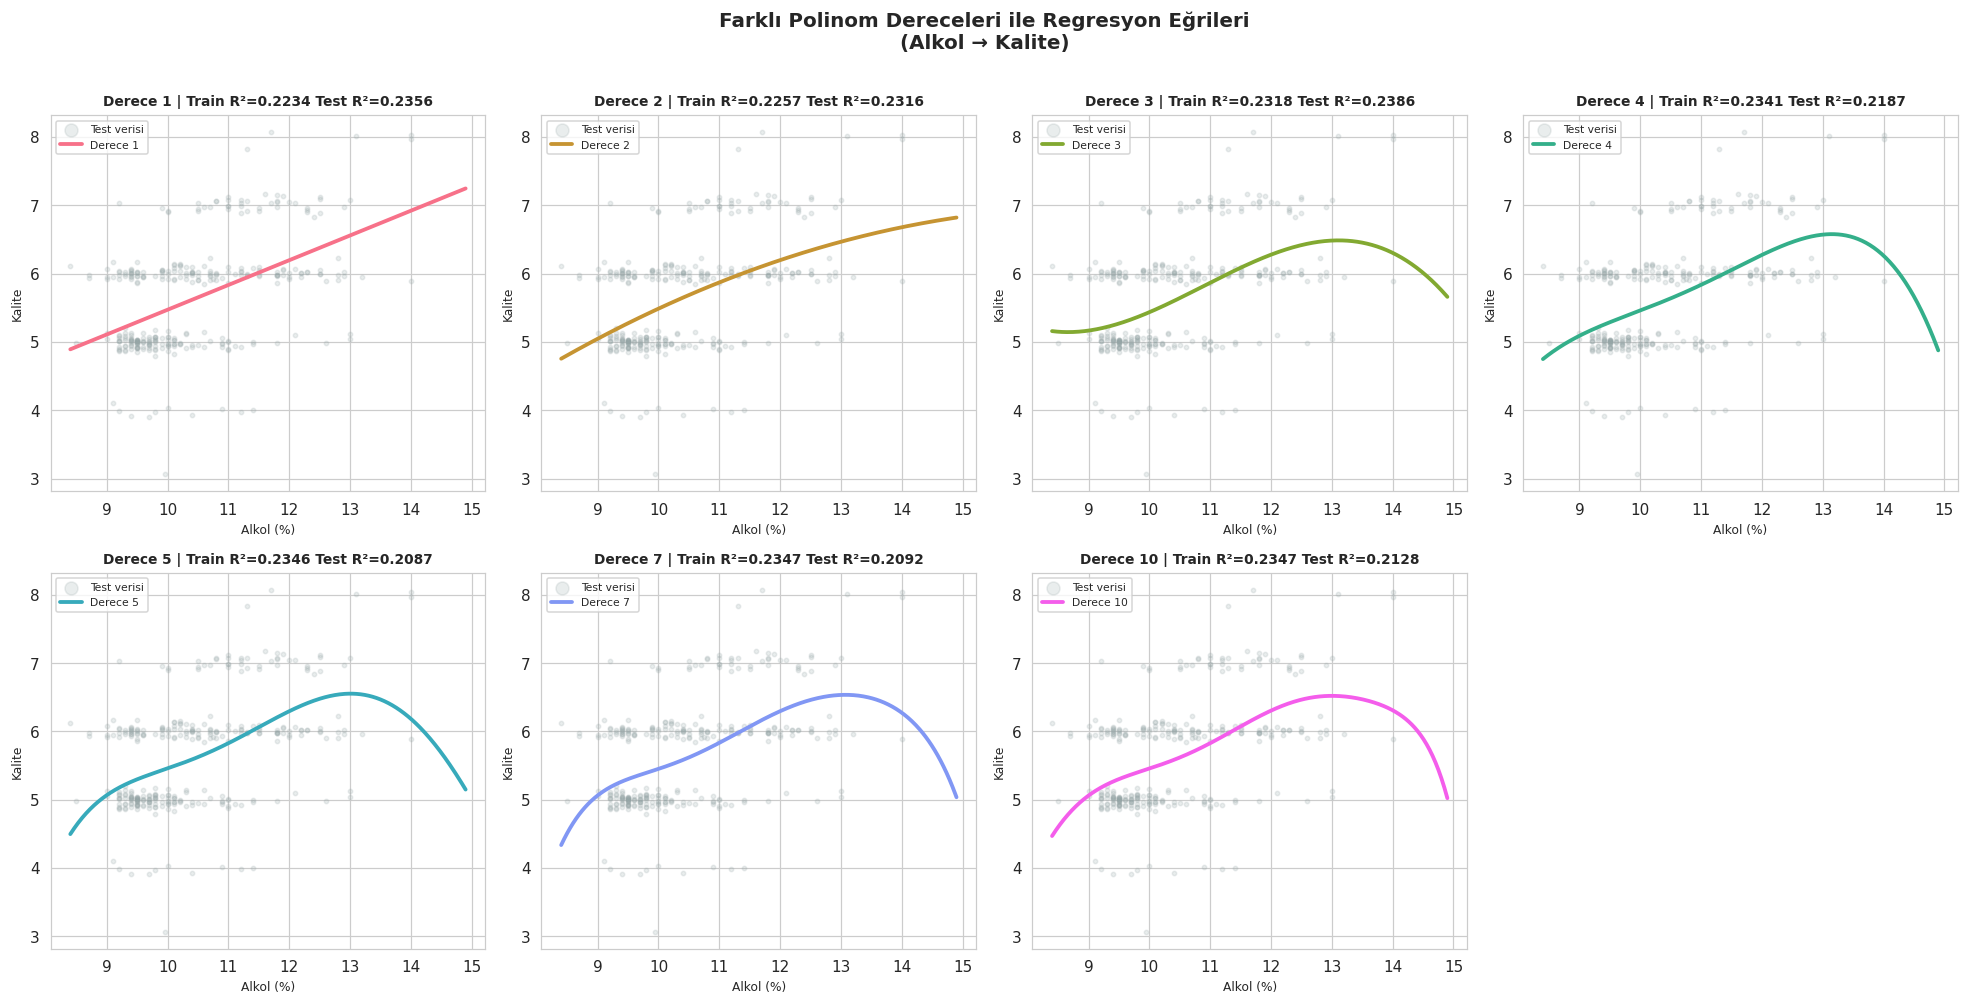

In [ ]:
fig, axes = plt.subplots(2, 4, figsize=(18, 9))
axes = axes.flatten()

X_line = np.linspace(X.min(), X.max(), 400).reshape(-1, 1)

palette = sns.color_palette('husl', len(degrees))

rng = np.random.default_rng(42)
jitter_test = rng.normal(0, 0.08, size=len(y_test))

for i, degree in enumerate(degrees):
    ax = axes[i]
    model = models[degree]
    row   = results_df[results_df['Derece'] == degree].iloc[0]

    ax.scatter(X_test, y_test + jitter_test,
               alpha=0.2, s=8, color='#95a5a6', label='Test verisi')

    ax.plot(X_line, model.predict(X_line),
            color=palette[i], linewidth=2.5, label=f'Derece {degree}')

    ax.set_title(f'Derece {degree} | Train R²={row["Train R²"]:.4f} Test R²={row["Test R²"]:.4f}', fontsize=9, fontweight='bold')
    ax.set_xlabel('Alkol (%)', fontsize=8)
    ax.set_ylabel('Kalite', fontsize=8)
    ax.legend(fontsize=7, markerscale=3)

if len(degrees) < len(axes):
    for j in range(len(degrees), len(axes)):
        axes[j].set_visible(False)

fig.suptitle('Farklı Polinom Dereceleri ile Regresyon Eğrileri\n(Alkol → Kalite)',
             fontsize=13, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

print('💡 Yorum:')
print('  • Derece 1 (doğrusal): Alkol arttıkça kalite ortalamada hafifçe yükseliyor.')
print('  • Derece 2-3: Çok hafif bir eğrisellik kazanıyor, ama fark küçük.')
print('  • Derece 7-10: Eğri gereksiz yere bükülüyor — overfitting belirtisi.')

##  📉 Model Performans Karşılaştırması

🏆 En iyi model: Derece 3
   Test R²   = 0.2386
   Test RMSE = 0.7054 kalite puanı


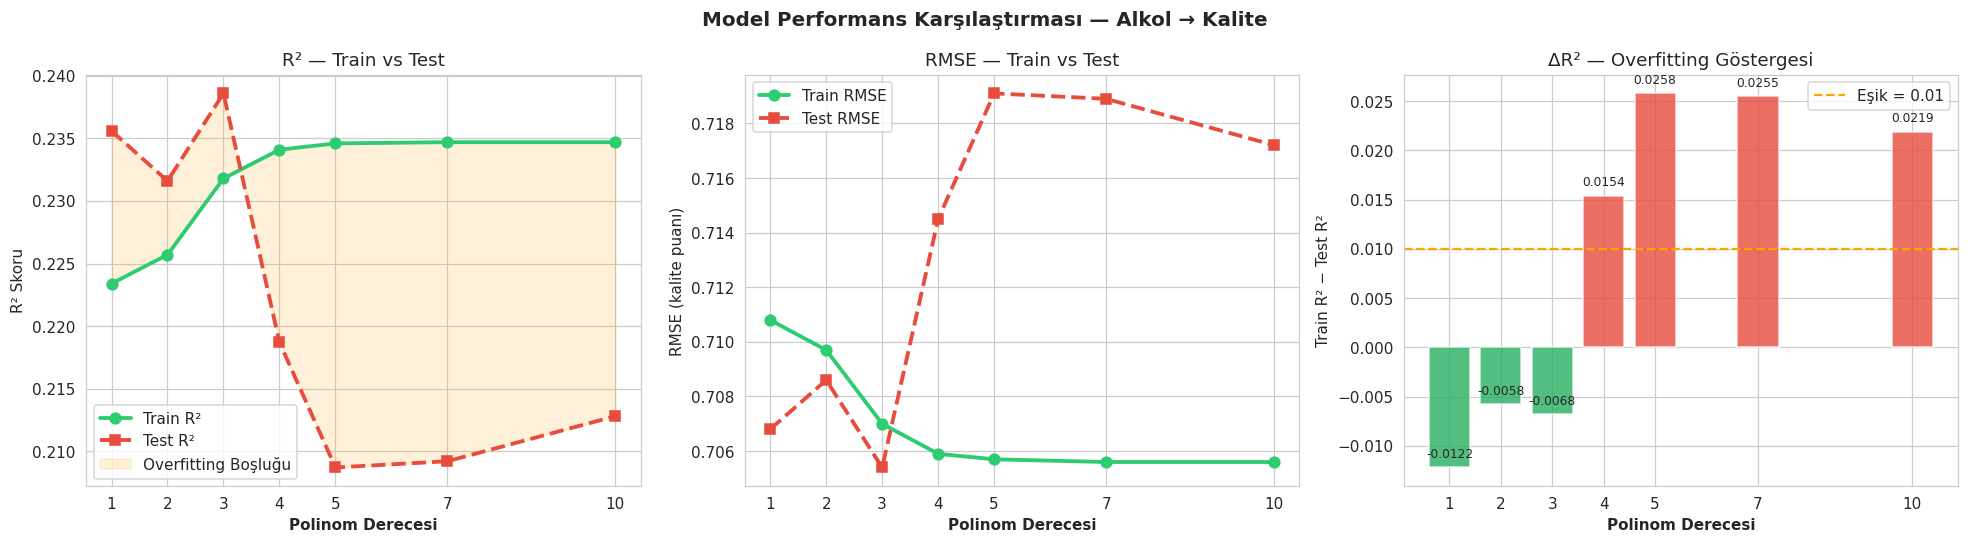

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle('Model Performans Karşılaştırması — Alkol → Kalite', fontsize=13, fontweight='bold')

x_ticks = results_df['Derece'].tolist()

axes[0].plot(results_df['Derece'], results_df['Train R²'],
             'o-', color='#2ecc71', linewidth=2.5, markersize=7, label='Train R²')
axes[0].plot(results_df['Derece'], results_df['Test R²'],
             's--', color='#e74c3c', linewidth=2.5, markersize=7, label='Test R²')
axes[0].fill_between(results_df['Derece'],
                     results_df['Train R²'], results_df['Test R²'],
                     alpha=0.15, color='orange', label='Overfitting Boşluğu')
axes[0].set_xlabel('Polinom Derecesi', fontweight='bold')
axes[0].set_ylabel('R² Skoru')
axes[0].set_title('R² — Train vs Test')
axes[0].legend()
axes[0].set_xticks(x_ticks)

axes[1].plot(results_df['Derece'], results_df['Train RMSE'],
             'o-', color='#2ecc71', linewidth=2.5, markersize=7, label='Train RMSE')
axes[1].plot(results_df['Derece'], results_df['Test RMSE'],
             's--', color='#e74c3c', linewidth=2.5, markersize=7, label='Test RMSE')
axes[1].set_xlabel('Polinom Derecesi', fontweight='bold')
axes[1].set_ylabel('RMSE (kalite puanı)')
axes[1].set_title('RMSE — Train vs Test')
axes[1].legend()
axes[1].set_xticks(x_ticks)

colors_bar = ['#27ae60' if v < 0.01 else '#e74c3c' for v in results_df['Δ R²']]
bars = axes[2].bar(results_df['Derece'], results_df['Δ R²'], color=colors_bar, alpha=0.8)
axes[2].axhline(y=0.01, color='orange', linestyle='--', linewidth=1.5, label='Eşik = 0.01')
axes[2].set_xlabel('Polinom Derecesi', fontweight='bold')
axes[2].set_ylabel('Train R² − Test R²')
axes[2].set_title('ΔR² — Overfitting Göstergesi')
axes[2].legend()
axes[2].set_xticks(x_ticks)

for bar, val in zip(bars, results_df['Δ R²']):
    axes[2].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.0007,
                 f'{val:.4f}', ha='center', va='bottom', fontsize=8)

plt.tight_layout()
plt.show()

best_row = results_df.loc[results_df['Test R²'].idxmax()]
print(f'🏆 En iyi model: Derece {int(best_row["Derece"])}')
print(f'   Test R²   = {best_row["Test R²"]:.4f}')
print(f'   Test RMSE = {best_row["Test RMSE"]:.4f} kalite puanı')

###  K-Fold Cross-Validation ile Derece Seçimi



In [ ]:
print('🔄 5-Fold Cross-Validation Sonuçları:')
print('─' * 55)

kf = KFold(n_splits=5, shuffle=True, random_state=42)
cv_results = []

for degree in degrees:
    model = make_pipeline(
        PolynomialFeatures(degree=degree),
        LinearRegression()
    )
    cv_scores = cross_val_score(model, X, y, cv=kf, scoring='r2')

    cv_results.append({
        'Derece'   : degree,
        'CV R² Ort': round(cv_scores.mean(), 4),
        'CV R² Std': round(cv_scores.std(),  4),
        'Min'      : round(cv_scores.min(),   4),
        'Max'      : round(cv_scores.max(),   4),
    })
    print(f'Derece {degree:2d} | CV R² = {cv_scores.mean():.4f} ± {cv_scores.std():.4f} | [{cv_scores.min():.4f}, {cv_scores.max():.4f}]')

cv_df = pd.DataFrame(cv_results)

print()
print('─' * 55)
best_cv_degree = cv_df.loc[cv_df['CV R² Ort'].idxmax(), 'Derece']
print(f'🏆 Cross-Validation a göre en iyi derece: {int(best_cv_degree)}')
print()
print('💡 Std ne kadar küçükse model o kadar KARARLIDIR (stabil).')
print('   Yüksek std → model bazı fold\'lara çok iyi, bazılarına kötü uyuyor.')
print('   Derece 7 ve 10 da Std büyüyor — yüksek dereceler tahminleri dengesizleştiriyor.')

🔄 5-Fold Cross-Validation Sonuçları:
───────────────────────────────────────────────────────
Derece  1 | CV R² = 0.2242 ± 0.0609 | [0.1265, 0.3085]
Derece  2 | CV R² = 0.2241 ± 0.0630 | [0.1224, 0.3110]
Derece  3 | CV R² = 0.2291 ± 0.0649 | [0.1168, 0.3055]
Derece  4 | CV R² = 0.2124 ± 0.0598 | [0.1165, 0.3054]
Derece  5 | CV R² = 0.2097 ± 0.0598 | [0.1171, 0.3061]
Derece  7 | CV R² = 0.1125 ± 0.1995 | [-0.2664, 0.3062]
Derece 10 | CV R² = -0.0157 ± 0.4526 | [-0.9123, 0.3064]

───────────────────────────────────────────────────────
🏆 Cross-Validation a göre en iyi derece: 3

💡 Std ne kadar küçükse model o kadar KARARLIDIR (stabil).
   Yüksek std → model bazı fold'lara çok iyi, bazılarına kötü uyuyor.
   Derece 7 ve 10 da Std büyüyor — yüksek dereceler tahminleri dengesizleştiriyor.


##  🏆 En İyi Model — Detaylı Analiz


🏆 Seçilen Model: 3. Derece Polinom
   Train R²   = 0.23180
   Test  R²   = 0.23856
   Test  RMSE = 0.7054 kalite puanı

💡 Artık Analizi İçgörüleri:
  • Ortalama artık ≈ 0.0514  (≈0 olması iyi — tarafsız model)
  • Artık std       = 0.7035
  • Kalite tam sayı olduğundan artıklar yatay şeritler halinde görünüyor — bu beklenen bir durum.
  • R² düşük olsa da model sistematik bir sapma göstermiyor, sadece açıklayıcı gücü sınırlı.


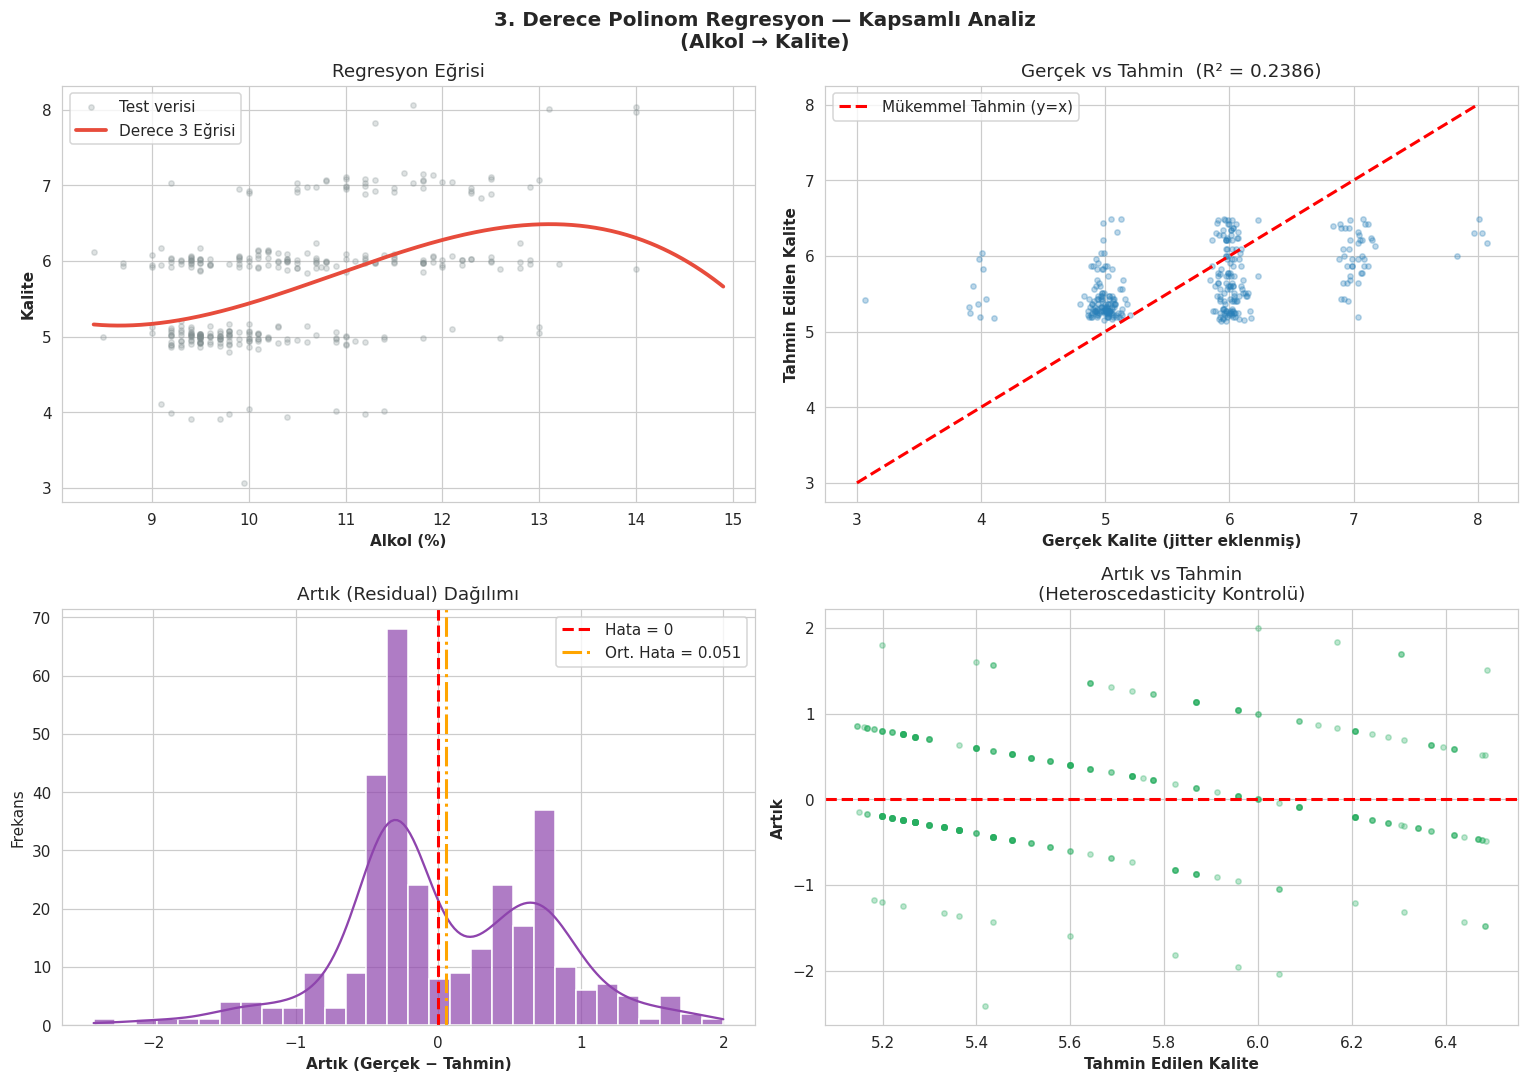

In [ ]:
best_degree = int(results_df.loc[results_df['Test R²'].idxmax(), 'Derece'])
best_model  = models[best_degree]

y_test_pred  = best_model.predict(X_test)
y_train_pred = best_model.predict(X_train)
residuals    = y_test - y_test_pred

print(f'🏆 Seçilen Model: {best_degree}. Derece Polinom')
print(f'   Train R²   = {r2_score(y_train, y_train_pred):.5f}')
print(f'   Test  R²   = {r2_score(y_test, y_test_pred):.5f}')
print(f'   Test  RMSE = {np.sqrt(mean_squared_error(y_test, y_test_pred)):.4f} kalite puanı')
print()

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle(f'{best_degree}. Derece Polinom Regresyon — Kapsamlı Analiz\n(Alkol → Kalite)',
             fontsize=13, fontweight='bold')

rng = np.random.default_rng(42)
jitter_test = rng.normal(0, 0.08, size=len(y_test))
axes[0,0].scatter(X_test, y_test + jitter_test,
                  alpha=0.25, s=12, color='#7f8c8d', label='Test verisi')
axes[0,0].plot(X_line, best_model.predict(X_line),
               color='#e74c3c', linewidth=2.5, label=f'Derece {best_degree} Eğrisi')
axes[0,0].set_xlabel('Alkol (%)', fontweight='bold')
axes[0,0].set_ylabel('Kalite', fontweight='bold')
axes[0,0].set_title('Regresyon Eğrisi')
axes[0,0].legend()

axes[0,1].scatter(y_test + jitter_test, y_test_pred,
                  alpha=0.3, s=12, color='#2980b9')
lims = [min(y_test.min(), y_test_pred.min()), max(y_test.max(), y_test_pred.max())]
axes[0,1].plot(lims, lims, 'r--', linewidth=2, label='Mükemmel Tahmin (y=x)')
axes[0,1].set_xlabel('Gerçek Kalite (jitter eklenmiş)', fontweight='bold')
axes[0,1].set_ylabel('Tahmin Edilen Kalite', fontweight='bold')
axes[0,1].set_title(f'Gerçek vs Tahmin  (R² = {r2_score(y_test, y_test_pred):.4f})')
axes[0,1].legend()

sns.histplot(residuals, bins=30, kde=True, color='#8e44ad', alpha=0.7, ax=axes[1,0])
axes[1,0].axvline(0, color='red', linestyle='--', linewidth=2, label='Hata = 0')
axes[1,0].axvline(residuals.mean(), color='orange', linestyle='-.',
                  linewidth=2, label=f'Ort. Hata = {residuals.mean():.3f}')
axes[1,0].set_xlabel('Artık (Gerçek − Tahmin)', fontweight='bold')
axes[1,0].set_ylabel('Frekans')
axes[1,0].set_title('Artık (Residual) Dağılımı')
axes[1,0].legend()

axes[1,1].scatter(y_test_pred, residuals,
                  alpha=0.3, s=12, color='#27ae60')
axes[1,1].axhline(0, color='red', linestyle='--', linewidth=2)
axes[1,1].set_xlabel('Tahmin Edilen Kalite', fontweight='bold')
axes[1,1].set_ylabel('Artık', fontweight='bold')
axes[1,1].set_title('Artık vs Tahmin\n(Heteroscedasticity Kontrolü)')

plt.tight_layout()
plt.show()

print('💡 Artık Analizi İçgörüleri:')
print(f'  • Ortalama artık ≈ {residuals.mean():.4f}  (≈0 olması iyi — tarafsız model)')
print(f'  • Artık std       = {residuals.std():.4f}')
print(f'  • Kalite tam sayı olduğundan artıklar yatay şeritler halinde görünüyor — bu beklenen bir durum.')
print(f'  • R² düşük olsa da model sistematik bir sapma göstermiyor, sadece açıklayıcı gücü sınırlı.')

##  🔎 Model Katsayılarının İncelenmesi


📐 3. Derece Polinom Katsayıları:
──────────────────────────────────────────────────
  β₀ (intercept): 40.240451

  β0 (1              ): +0.000000
  β1 (alcohol        ): -10.391895
  β2 (alcohol^2      ): +0.996165
  β3 (alcohol^3      ): -0.030502

📝 Model Denklemi:
  ŷ = 40.2405 + (-10.3919)·x^1 + (+0.9962)·x^2 + (-0.0305)·x^3



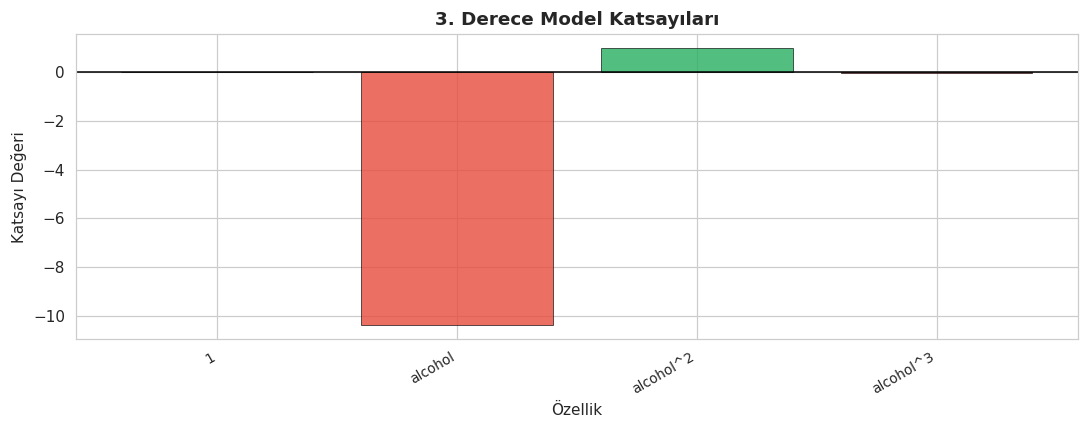

In [ ]:
lr_step   = best_model.named_steps['linearregression']
pf_step   = best_model.named_steps['polynomialfeatures']

intercept = lr_step.intercept_
coeffs    = lr_step.coef_
feat_names = pf_step.get_feature_names_out(['alcohol'])

print(f'📐 {best_degree}. Derece Polinom Katsayıları:')
print('─' * 50)
print(f'  β₀ (intercept): {intercept:.6f}')
print()

for i, (name, coef) in enumerate(zip(feat_names, coeffs)):
    print(f'  β{i} ({name:15s}): {coef:+.6f}')

print()

print('📝 Model Denklemi:')
equation = f'  ŷ = {intercept:.4f}'
for i, (name, coef) in enumerate(zip(feat_names[1:], coeffs[1:]), 1):  # bias'ı atla
    equation += f' + ({coef:+.4f})·x^{i}'
print(equation)
print()

fig, ax = plt.subplots(figsize=(10, 4))
coef_vals = list(coeffs)
coef_names = [str(n) for n in feat_names]
colors_c = ['#27ae60' if v >= 0 else '#e74c3c' for v in coef_vals]

ax.bar(range(len(coef_vals)), coef_vals, color=colors_c, alpha=0.8, edgecolor='black', linewidth=0.5)
ax.axhline(0, color='black', linewidth=1)
ax.set_xticks(range(len(coef_names)))
ax.set_xticklabels(coef_names, rotation=30, ha='right', fontsize=9)
ax.set_xlabel('Özellik')
ax.set_ylabel('Katsayı Değeri')
ax.set_title(f'{best_degree}. Derece Model Katsayıları', fontweight='bold')
plt.tight_layout()
plt.show()

## Uçucu Asitlik → Kalite Tahmini


📋 Uçucu Asitlik → Kalite Sonuç Tablosu:
 Derece  Train R²  Test R²  Test RMSE
      1    0.1432   0.1848     0.7299
      2    0.1453   0.1857     0.7295
      3    0.1495   0.1825     0.7309
      5    0.1520   0.1797     0.7322
      7    0.1592   0.1724     0.7354

💡 Yorum:
  • Uçucu asitlik ile kalite arasındaki R² değerleri, alkol senaryosundan bile daha düşük.
  • Bu, tek başına uçucu asitliğin kaliteyi alkolden daha az açıkladığını gösteriyor.


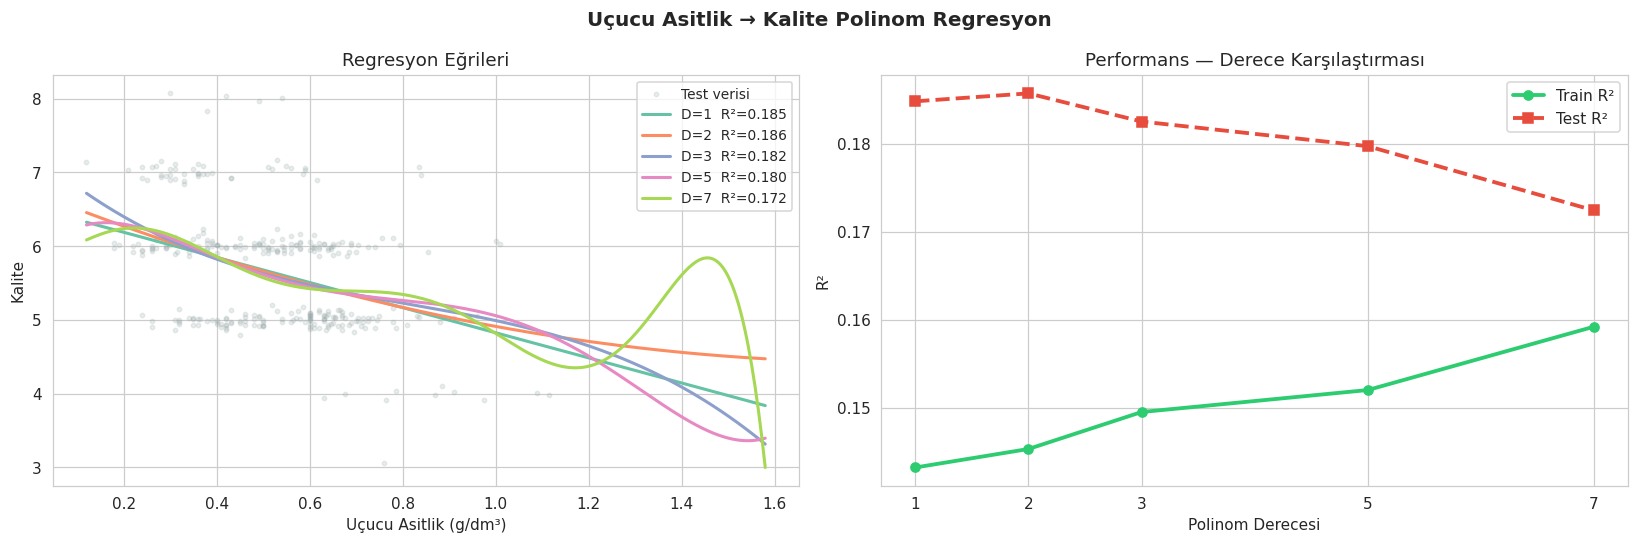

In [ ]:
X2 = data[['volatile acidity']].values
y2 = data['quality'].values

X2_train, X2_test, y2_train, y2_test = train_test_split(
    X2, y2, test_size=0.20, random_state=42
)

degrees2  = [1, 2, 3, 5, 7]
models2   = {}
results2  = []

for degree in degrees2:
    model = make_pipeline(PolynomialFeatures(degree), LinearRegression())
    model.fit(X2_train, y2_train)
    models2[degree] = model

    y2_test_pred  = model.predict(X2_test)
    y2_train_pred = model.predict(X2_train)

    results2.append({
        'Derece'    : degree,
        'Train R²'  : round(r2_score(y2_train, y2_train_pred), 4),
        'Test R²'   : round(r2_score(y2_test,  y2_test_pred),  4),
        'Test RMSE' : round(np.sqrt(mean_squared_error(y2_test, y2_test_pred)), 4),
    })

results2_df = pd.DataFrame(results2)

fig, axes = plt.subplots(1, 2, figsize=(15, 5))
fig.suptitle('Uçucu Asitlik → Kalite Polinom Regresyon', fontsize=13, fontweight='bold')

rng = np.random.default_rng(42)
jitter2 = rng.normal(0, 0.08, size=len(y2_test))
axes[0].scatter(X2_test, y2_test + jitter2,
                alpha=0.2, s=8, color='#95a5a6', label='Test verisi')

pal2 = sns.color_palette('Set2', len(degrees2))
X2_line = np.linspace(X2.min(), X2.max(), 400).reshape(-1, 1)

for j, degree in enumerate(degrees2):
    y_line = models2[degree].predict(X2_line)
    axes[0].plot(X2_line, y_line, color=pal2[j], linewidth=2,
                 label=f'D={degree}  R²={results2_df.iloc[j]["Test R²"]:.3f}')

axes[0].set_xlabel('Uçucu Asitlik (g/dm³)')
axes[0].set_ylabel('Kalite')
axes[0].set_title('Regresyon Eğrileri')
axes[0].legend(fontsize=9)

axes[1].plot(results2_df['Derece'], results2_df['Train R²'],
             'o-', linewidth=2.5, color='#2ecc71', label='Train R²')
axes[1].plot(results2_df['Derece'], results2_df['Test R²'],
             's--', linewidth=2.5, color='#e74c3c', label='Test R²')
axes[1].set_xlabel('Polinom Derecesi')
axes[1].set_ylabel('R²')
axes[1].set_title('Performans — Derece Karşılaştırması')
axes[1].legend()
axes[1].set_xticks(degrees2)

plt.tight_layout()
plt.show()

print('📋 Uçucu Asitlik → Kalite Sonuç Tablosu:')
print(results2_df.to_string(index=False))
print()
print('💡 Yorum:')
print('  • Uçucu asitlik ile kalite arasındaki R² değerleri, alkol senaryosundan bile daha düşük.')
print('  • Bu, tek başına uçucu asitliğin kaliteyi alkolden daha az açıkladığını gösteriyor.')